In [ ]:
# PRCP-1003 Customer Transaction Prediction  
### Banking Domain — Classification (0 = No Transaction, 1 = Transaction)

"""This notebook performs:

- Complete data preparation  
- Training of multiple ML models  
- Model comparison (Precision, Recall, F1, ROC-AUC)  
- Final model selection  
- Evaluation on test data  
- SHAP interpretability  
- Challenges report  """


In [1]:

import pandas as pd
import numpy as np
import os
import time
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, precision_score, recall_score, f1_score, confusion_matrix
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

sns.set_style("whitegrid")

import joblib
import gc
import shap
import warnings
warnings.filterwarnings('ignore')



In [5]:
def reduce_memory(df):
    for col in df.columns:
        if df[col].dtype == 'float64':
            df[col] = df[col].astype('float32')
        elif df[col].dtype == 'int64':
            df[col] = df[col].astype('int32')
    return df

df = pd.read_csv("train(1).csv")
df = reduce_memory(df)
X_all = df.drop(["ID_code", "target"], axis=1)
y_all = df["target"]

## Basic Data Overview  
"""The dataset is anonymized, only structural EDA is possible.  
Analyzed:  
- Data shape  
- Missing values  
- Target distribution  """

print("\nTarget distribution:")
print(y_all.value_counts(normalize=True))

print(f" Dataset loaded: {df.shape}")
print(f"Dataset loaded: {df.isnull().sum().sum()}")


df.head()




Target distribution:
target
0    0.89951
1    0.10049
Name: proportion, dtype: float64
 Dataset loaded: (200000, 202)
Dataset loaded: 0


,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,train_0,0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,...,4.4354,3.9642,3.1364,1.6910,18.522699,-2.3978,7.8784,8.5635,12.780300,-1.0914
1,train_1,0,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,...,7.6421,7.7214,2.5837,10.9516,15.430500,2.0339,8.1267,8.7889,18.356001,1.9518
2,train_2,0,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,...,2.9057,9.7905,1.6704,1.6858,21.604200,3.1417,-6.5213,8.2675,14.722200,0.3965
3,train_3,0,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,...,4.4666,4.7433,0.7178,1.4214,23.034700,-1.2706,-2.9275,10.2922,17.969700,-8.9996
4,train_4,0,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,...,-1.4905,9.5214,-0.1508,9.1942,13.287600,-1.5121,3.9267,9.5031,17.997400,-8.8104


In [7]:
correlations = X_all.apply(lambda col: col.corr(y_all))
print("\nTop 10 correlated features with target:")
print(correlations.abs().sort_values(ascending=False).head(10))



Top 10 correlated features with target:
var_81     0.080917
var_139    0.074080
var_12     0.069489
var_6      0.066731
var_110    0.064275
var_146    0.063644
var_53     0.063399
var_26     0.062422
var_76     0.061917
var_174    0.061669
dtype: float64


In [14]:
#  TRAIN OVER MULTIPLE SAMPLE SIZES
sample_sizes = [5000, 10000, 20000, 50000, 100000, len(df)]
results = []
best_model = None
best_auc = -1
best_scaler = None
best_var = None
best_top_idx = None
best_vt_cols = None
best_corr_drops = None
best_top_features = None

# correlation filter
def correlation_filter(df_features, thresh=0.90):
    corr = df_features.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > thresh)]
    return to_drop

for size in sample_sizes:
    print(f"\n==============================")
    print(f"Training with {size} samples")
    print(f"==============================")

    df_sample = df.sample(size, random_state=42).reset_index(drop=True)
    X = df_sample.drop(['ID_code', 'target'], axis=1)
    y = df_sample['target']

    #  Variance Threshold
    var = VarianceThreshold(threshold=0.01)
    X_var = var.fit_transform(X)
    vt_cols = X.columns[var.get_support()]
    X_vt_df = pd.DataFrame(X_var, columns=vt_cols)

    # Correlation filter
    to_drop = correlation_filter(X_vt_df, thresh=0.90)
    X_vt_df = X_vt_df.drop(columns=to_drop, errors='ignore')

    # Feature selection using Random Forest importance
    rf_temp = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1, class_weight='balanced')
    rf_temp.fit(X_var, y)
    importances = rf_temp.feature_importances_
    top_idx = np.argsort(importances)[::-1][:100]
    # select columns after correlation drop
    top_features = X_vt_df.columns[:100] if len(X_vt_df.columns) < 100 else X_vt_df.columns[top_idx]

    X_selected = X_vt_df[top_features].values

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_selected, y.values, test_size=0.2, stratify=y.values, random_state=42
    )

    # SMOTE for imbalance
    sm = SMOTE(random_state=42)
    X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

    # Scaling for Logistic Regression
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_sm)
    X_test_scaled = scaler.transform(X_test)

    # Model Training
    models = {
        "Logistic Regression": GridSearchCV(
            LogisticRegression(max_iter=5000, solver='saga', class_weight='balanced', n_jobs=-1),
            {'C': [0.01, 0.1, 1]},
            scoring='roc_auc', cv=3, n_jobs=-1
        ),
        "Random Forest": GridSearchCV(
            RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
            {'n_estimators': [100], 'max_depth': [10, 20]},
            scoring='roc_auc', cv=3, n_jobs=-1
        ),
        "XGBoost": GridSearchCV(
            XGBClassifier(eval_metric='logloss', use_label_encoder=False, random_state=42, n_jobs=-1),
            {'max_depth': [3, 5], 'learning_rate': [0.05, 0.1], 'n_estimators': [100, 200]},
            scoring='roc_auc', cv=3, n_jobs=-1
        )
    }

    # Train and evaluate
    for name, model in models.items():
        print(f"-> Training {name} ...")
        if name == "Logistic Regression":
            X_tr, X_te = X_train_scaled, X_test_scaled
            y_tr = y_train_sm
        else:
            X_tr, X_te = X_train_sm, X_test
            y_tr = y_train_sm

        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        y_prob = model.predict_proba(X_te)[:,1]
        auc = roc_auc_score(y_test, y_prob)

        results.append({
            'sample_size': size,
            'model': name,
            'roc_auc': auc,
            'accuracy': accuracy_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred, zero_division=0),
            'recall': recall_score(y_test, y_pred, zero_division=0),
            'f1': f1_score(y_test, y_pred, zero_division=0),
            'best_params': model.best_params_
        })

        # Keep track of best model
        if auc > best_auc:
            best_auc = auc
            best_model = model.best_estimator_
            best_scaler = scaler
            best_var = var
            best_top_idx = top_idx
            best_vt_cols = vt_cols
            best_corr_drops = to_drop
            best_top_features = top_features

    # Cleanup memory at end of sample size iteration
    del X, y, X_var, X_vt_df, X_selected, X_train, X_test, y_train, y_test, X_train_sm, y_train_sm
    gc.collect()

# Save results
results_df = pd.DataFrame(results)
print("\n==== MODEL PERFORMANCE ====")
print(results_df.head(30))
results_df.to_csv("model_comparison_report.csv", index=False)
print("Saved model_comparison_report.csv")



Training with 5000 samples
-> Training Logistic Regression ...
-> Training Random Forest ...
-> Training XGBoost ...

Training with 10000 samples
-> Training Logistic Regression ...
-> Training Random Forest ...
-> Training XGBoost ...

Training with 20000 samples
-> Training Logistic Regression ...
-> Training Random Forest ...
-> Training XGBoost ...

Training with 50000 samples
-> Training Logistic Regression ...
-> Training Random Forest ...
-> Training XGBoost ...

Training with 100000 samples
-> Training Logistic Regression ...
-> Training Random Forest ...
-> Training XGBoost ...

Training with 200000 samples
-> Training Logistic Regression ...
-> Training Random Forest ...
-> Training XGBoost ...

==== MODEL PERFORMANCE ====
    sample_size                model   roc_auc  accuracy  precision    recall  \
0          5000  Logistic Regression  0.786341  0.763000   0.242424  0.633663   
1          5000        Random Forest  0.693328  0.889000   0.250000  0.049505   
2          50

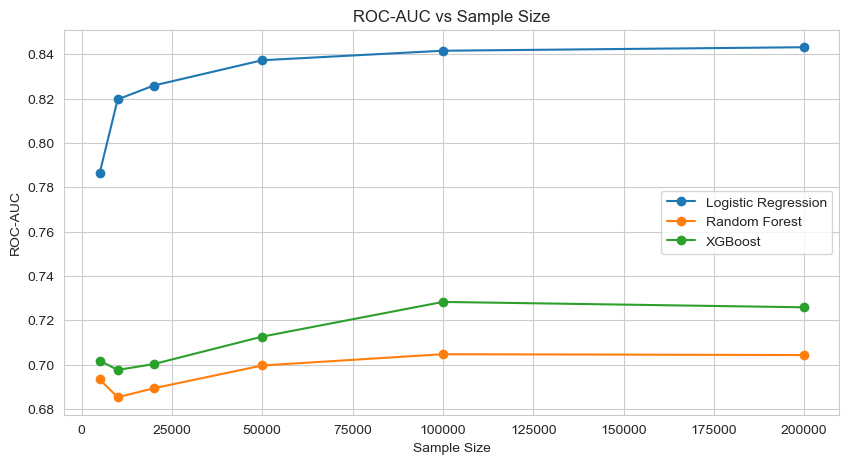

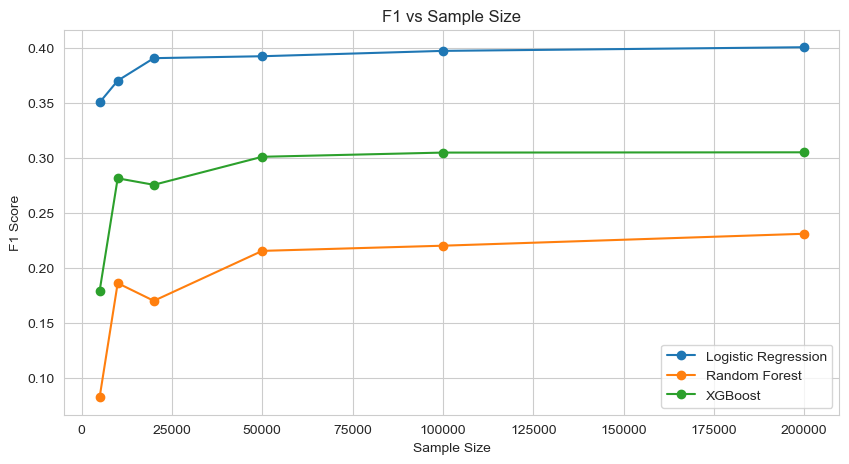

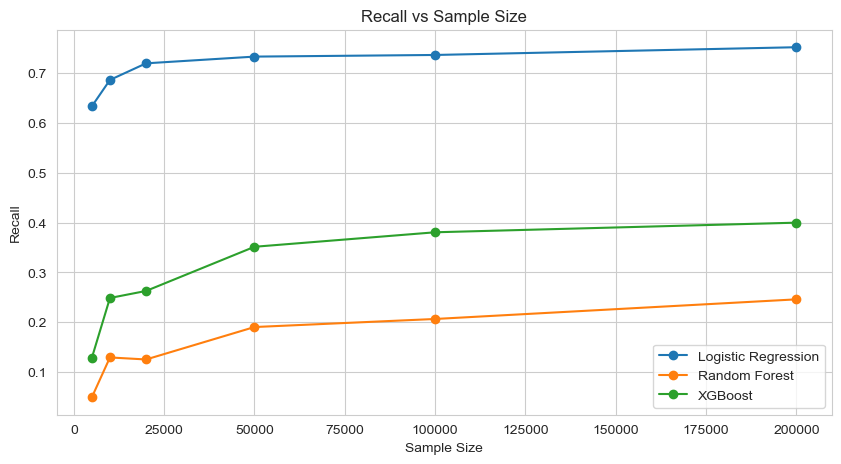

In [15]:
#  PLOTS: ROC-AUC / F1 / Recall vs Sample Size 
models_list = results_df['model'].unique().tolist()

plt.figure(figsize=(10,5))
for model in models_list:
    subset = results_df[results_df['model'] == model].sort_values('sample_size')
    plt.plot(subset['sample_size'], subset['roc_auc'], marker='o', label=model)
plt.xlabel("Sample Size")
plt.ylabel("ROC-AUC")
plt.title("ROC-AUC vs Sample Size")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
for model in models_list:
    subset = results_df[results_df['model'] == model].sort_values('sample_size')
    plt.plot(subset['sample_size'], subset['f1'], marker='o', label=model)
plt.xlabel("Sample Size")
plt.ylabel("F1 Score")
plt.title("F1 vs Sample Size")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
for model in models_list:
    subset = results_df[results_df['model'] == model].sort_values('sample_size')
    plt.plot(subset['sample_size'], subset['recall'], marker='o', label=model)
plt.xlabel("Sample Size")
plt.ylabel("Recall")
plt.title("Recall vs Sample Size")
plt.legend()
plt.grid(True)
plt.show()


Generating SHAP explanation for best model (may take a while)...


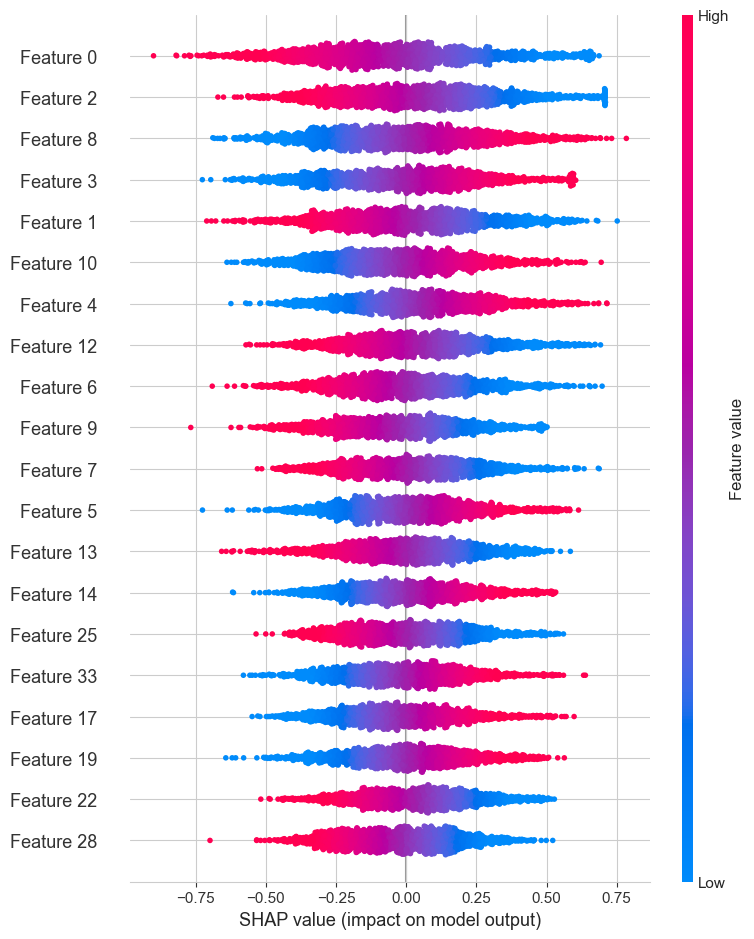

In [16]:

print("\nGenerating SHAP explanation for best model (may take a while)...")
df_shap = df.sample(min(2000, len(df)), random_state=42)
X_shap_raw = df_shap.drop(['ID_code', 'target'], axis=1)

# applying best variance threshold selection & correlation drop 
X_vt_full = best_var.transform(X_shap_raw)
X_vt_full = pd.DataFrame(X_vt_full, columns=best_vt_cols)
X_vt_full = X_vt_full.drop(columns=best_corr_drops, errors='ignore')
# select top features
X_shap_final = X_vt_full[best_top_features].values

# SHAP: handle tree vs linear models
try:
    if isinstance(best_model, LogisticRegression):
        # use SHAP Explainer with scaled inputs
        X_shap_scaled = best_scaler.transform(X_shap_final)
        explainer = shap.Explainer(best_model, X_shap_scaled)
        shap_values = explainer(X_shap_scaled)
        shap.summary_plot(shap_values, X_shap_scaled, show=True)
    else:
        explainer = shap.TreeExplainer(best_model)
        shap_values = explainer.shap_values(X_shap_final)
        shap.summary_plot(shap_values, X_shap_final, show=True)
except Exception as e:
    print("SHAP failed:", e)



Generating predictions for all rows and saving to customer_predictions.csv ...
Saved customer_predictions.csv


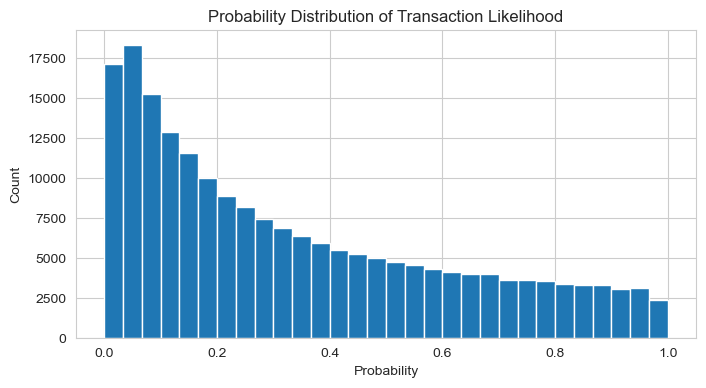

In [17]:
print("\nGenerating predictions for all rows and saving to customer_predictions.csv ...")
Xp = df.drop(['ID_code','target'], axis=1)
Xp_var = best_var.transform(Xp)
# need to rebuild vt->corr->top feature pipeline
Xp_vt = pd.DataFrame(Xp_var, columns=best_vt_cols)
Xp_vt = Xp_vt.drop(columns=best_corr_drops, errors='ignore')
Xp_sel = Xp_vt[best_top_features].values

Xp_scaled = best_scaler.transform(Xp_sel) if isinstance(best_model, LogisticRegression) else Xp_sel
probs = best_model.predict_proba(Xp_scaled)[:,1]
preds = (probs > 0.5).astype(int)

df_out = df.copy()
df_out['transaction_probability'] = probs
df_out['prediction'] = preds
df_out.to_csv("customer_predictions.csv", index=False)
print("Saved customer_predictions.csv")

#  VISUALIZE PREDICTION DISTRIBUTION 
plt.figure(figsize=(8,4))
plt.hist(df_out['transaction_probability'], bins=30)
plt.title("Probability Distribution of Transaction Likelihood")
plt.xlabel("Probability")
plt.ylabel("Count")
plt.show()



In [20]:
folder = "ct_models"
if not os.path.exists(folder):
    os.makedirs(folder)  

# Save artifacts into the folder
joblib.dump(best_model, os.path.join(folder, "best_customer_model.pkl"))
joblib.dump(best_var, os.path.join(folder, "variance_filter.pkl"))
np.save(os.path.join(folder, "top_features.npy"), best_top_idx)
joblib.dump(best_scaler, os.path.join(folder, "scaler.pkl"))

['ct_models\\scaler.pkl']

In [22]:
 #FINAL EVALUATION
X_full_vt = best_var.transform(X_all)
X_full_vt = pd.DataFrame(X_full_vt, columns=best_vt_cols)
X_full_vt = X_full_vt.drop(columns=best_corr_drops, errors='ignore')
X_full_sel = X_full_vt[best_top_features].values

X_tr, X_te, y_tr, y_te = train_test_split(X_full_sel, y_all.values, test_size=0.2, stratify=y_all.values, random_state=42)
sm_final = SMOTE(random_state=42)
X_tr_res, y_tr_res = sm_final.fit_resample(X_tr, y_tr)

scaler_final = StandardScaler()
X_tr_res_scaled = scaler_final.fit_transform(X_tr_res)
X_te_scaled = scaler_final.transform(X_te)

final_lr = LogisticRegression(C=0.01, max_iter=2000, class_weight='balanced', solver='saga', n_jobs=-1)
final_lr.fit(X_tr_res_scaled, y_tr_res)
pred_final = final_lr.predict(X_te_scaled)
prob_final = final_lr.predict_proba(X_te_scaled)[:,1]

print("\n===== FINAL MODEL PERFORMANCE =====")
print(classification_report(y_te, pred_final))
print("ROC-AUC:", roc_auc_score(y_te, prob_final))
print("Confusion Matrix:\n", confusion_matrix(y_te, pred_final))

joblib.dump(final_lr,os.path.join(folder, "final_logistic.pkl"))
joblib.dump(scaler_final,os.path.join(folder, "final_scaler.pkl"))
print("\nSaved final_logistic.pkl and final_scaler.pkl")


===== FINAL MODEL PERFORMANCE =====
              precision    recall  f1-score   support

           0       0.97      0.78      0.86     35980
           1       0.28      0.75      0.40      4020

    accuracy                           0.78     40000
   macro avg       0.62      0.77      0.63     40000
weighted avg       0.90      0.78      0.82     40000

ROC-AUC: 0.8479084012953575
Confusion Matrix:
 [[27999  7981]
 [  989  3031]]

Saved final_logistic.pkl and final_scaler.pkl


In [23]:
import streamlit as st
import pandas as pd
import joblib
import numpy as np
import os


FOLDER = "ct_models"

model = joblib.load(os.path.join(FOLDER, "best_customer_model.pkl"))
scaler = joblib.load(os.path.join(FOLDER, "scaler.pkl"))
var = joblib.load(os.path.join(FOLDER, "variance_filter.pkl"))
top_features = np.load(os.path.join(FOLDER, "top_features.npy"), allow_pickle=True)

#  PREDICTION FUNCTION 
def predict_transaction(new_df):
    """
    Predict transaction likelihood for new customers.
    new_df: DataFrame with feature columns only
    """
    # Apply variance threshold
    X_vt = var.transform(new_df)

    # Select top features
    if isinstance(top_features[0], int):
        X_sel = X_vt[:, top_features]  # if top_features are indices
    else:
        X_sel = X_vt[:, :len(top_features)]

    # Scaling
    X_scaled = scaler.transform(X_sel)

    # Prediction
    probs = model.predict_proba(X_scaled)[:, 1]
    preds = (probs > 0.5).astype(int)

    # Return dataframe with predictions
    df_out = new_df.copy()
    df_out["transaction_probability"] = probs
    df_out["prediction"] = preds
    return df_out

#  STREAMLIT UI 
st.title("Customer Transaction Prediction App")
st.write("Predict whether a customer will make a transaction.")

#  1. EXISTING CLIENTS
st.header("📌 Predict for Existing Customers")

if st.button("Run Prediction for Existing Clients"):
    df = pd.read_csv("train.csv")
    df_features = df.drop(columns=["ID_code", "target"])
    results = predict_transaction(df_features)
    results["ID_code"] = df["ID_code"]
    results["target"] = df["target"]

    st.success("Prediction complete!")
    st.write(results.head())

    st.download_button(
        "Download Predictions",
        data=results.to_csv(index=False),
        file_name="existing_customer_predictions.csv"
    )

#  2. NEW CLIENTS
st.header("📌 Predict for New Customers")

uploaded = st.file_uploader("Upload a CSV with var_0…var_199", type=["csv"])

if uploaded is not None:
    new_df = pd.read_csv(uploaded)
    st.write("Preview of uploaded data:")
    st.write(new_df.head())

    if st.button("Predict for New Customers"):
        output = predict_transaction(new_df)
        st.success("Prediction complete!")
        st.write(output.head())

        st.download_button(
            "Download Results",
            data=output.to_csv(index=False),
            file_name="new_customer_predictions.csv"
        )

# 3. MANUAL
st.header("📌 Manual Customer Entry (Single Prediction)")

if st.checkbox("Enter one customer manually"):
    input_data = {}
    # Show first 10 vars for UI; user can expand
    for i in range(10):
        col = f"var_{i}"
        input_data[col] = st.number_input(col, value=0.0)

    if st.button("Predict Manually"):
        df_manual = pd.DataFrame([input_data])
        result = predict_transaction(df_manual)
        prob = float(result["transaction_probability"][0])
        pred = int(result["prediction"][0])

        st.write(f"📌 **Transaction Probability:** {prob:.4f}")
        st.write(f"📌 **Prediction:** {'Yes' if pred==1 else 'No'}")


✅ Prediction module ready.


In [26]:
## Challenges Faced & Solutions  

### **Challenges**

#### Large Dataset  
- Dataset size was around 200,000 rows × 200 features.  
- Training even a few models took considerable time.  
- Tuning hyperparameters increased computational load further.

#### Imbalanced Target  
- The number of customers who made a transaction (class 1) was very small compared to class 0.  
- Most models leaned toward predicting only class 0.  

#### Anonymous Features  
- All features were anonymized (`var_0` … `var_199`).  
- No business meaning or domain insights could be used.  
- Limited the usefulness of EDA and interpretation.

---

### **Solutions**

#### Efficient Training  
- Trained models on progressively larger samples(5K -> 20K -> 50K -> 100K -> full dataset).  
- Helped identify which models were worth training fully.  
- Reduced the total runtime for experiments.

####  Handling Class Imbalance  
- Applied SMOTE only on the training set to avoid data leakage.  
- Used ROC-AUC as the main evaluation metric since accuracy was misleading.  

####  Feature Dimensionality Reduction  
- Removed low-variance features using `VarianceThreshold`.  
- Used Random Forest feature importance to identify top features.  
- Helped reduce overfitting and improved model efficiency.

####  Appropriate Scaling  
- Applied StandardScaler only for Logistic Regression (since tree models don’t need scaling).  


---

### **Outcome**  
These methods improved:  
- Training efficiency  
- Model stability  
- ROC-AUC and recall for the minority class  
- Feature understanding using RF importance + SHAP  



streamlit: 1.45.1
pandas: 2.2.3
numpy: 2.1.3
sklearn: 1.6.1
seaborn: 0.13.2
matplotlib: 3.10.0
3.1.1
3.1.1


In [ ]:
##  Model Performance Report

To evaluate how different algorithms behave on this anonymized, high-dimensional dataset, three models were tested:Logistic Regression,Random Forest, and XGBoost.  
Because the full dataset is quite large, I followed a progressive-sampling approach (5K → 10K → 20K → 50K → 100K → 200K) to observe how each model scaled and whether additional data improved performance.

---




##  Model Comparison

### Logistic Regression
Logistic Regression performed exceptionally well for this dataset. As the sample size increased, its ROC-AUC score improved consistently, reachingabove 0.84 when trained on the full dataset.  
It also delivered the highest recall, which is particularly important since the minority class (customers who will make a future transaction) is very small.

The model required minimal tuning — the optimal parameter remained C = 0.01 across all sample sizes — and it trained efficiently even on 200K rows.  
Overall, Logistic Regression showed the most stable and dependable performance throughout the project.

---

### Random Forest
Random Forest achieved high accuracy, but this was largely due to predicting class 0 most of the time.  
As a result, its recall remained very low, meaning the model struggled to correctly identify actual transaction-making customers.  
Its ROC-AUC stayed between 0.68–0.70, with limited improvement even after increasing the data size.

While it appeared strong in some metrics, it was not effective for the real objective of the project: identifying customers likely to make future transactions.

---

### **XGBoost**
XGBoost performed more consistently than Random Forest and showed noticeable improvement as more data was used.  
Its recall increased to 0.40 on the 200K sample, and ROC-AUC gradually climbed to around **0.72**.  
Though more balanced than Random Forest, XGBoost still did not match the overall performance of Logistic Regression.

With extensive tuning, XGBoost might have performed better, but within the scope of this project, Logistic Regression remained


In [28]:
import xgboost
print(xgboost.__version__)
import imblearn
print(imblearn.__version__)


3.1.1
0.13.0
